## Dataset Overview

In [14]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

TEAL  = '#2A9D8F'
AMBER = '#E9C46A'
DARK  = '#264653'

pd.set_option('display.max_columns', None)
df = pd.read_csv('/content/drive/MyDrive/final_year_project/Data/fraud_oracle_raw.csv')
df.head(5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [15]:
print("Dataset shape:", df.shape)
print(df.columns.tolist())

Dataset shape: (15420, 33)
['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']


In [16]:
summary = pd.DataFrame({
    'Data type': df.dtypes,
    'Missing values': df.isnull().sum(),
    'Unique values': df.nunique()
})
print("\nColumn summary:")
display(summary)


Column summary:


,Data type,Missing values,Unique values
Month,object,0,12
WeekOfMonth,int64,0,5
DayOfWeek,object,0,7
Make,object,0,19
AccidentArea,object,0,2
DayOfWeekClaimed,object,0,8
MonthClaimed,object,0,13
WeekOfMonthClaimed,int64,0,5
Sex,object,0,2
MaritalStatus,object,0,4


In [17]:
print("Total claims:", len(df))

print("Fraudulent claims:", df['FraudFound_P'].sum())

print("Legitimate claims:", len(df) - df['FraudFound_P'].sum())

print("Fraud rate:", df['FraudFound_P'].mean())

print("Years covered:", df['Year'].min(), "to", df['Year'].max())

Total claims: 15420
Fraudulent claims: 923
Legitimate claims: 14497
Fraud rate: 0.05985732814526589
Years covered: 1994 to 1996


In [22]:
df.describe(include='all')

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
count,15420,15420.000000,15420,15420,15420,15420,15420,15420.000000,15420,15420,15420.000000,15420,15420,15420,15420,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420,15420,15420,15420,15420,15420,15420,15420,15420,15420,15420,15420.000000,15420
unique,12,NaN,7,19,2,8,13,NaN,2,4,NaN,2,9,3,6,NaN,NaN,NaN,NaN,NaN,5,4,4,8,9,2,2,2,4,5,5,NaN,3
top,Jan,NaN,Monday,Pontiac,Urban,Monday,Jan,NaN,Male,Married,NaN,Policy Holder,Sedan - Collision,Sedan,20000 to 29000,NaN,NaN,NaN,NaN,NaN,more than 30,more than 30,2 to 4,7 years,31 to 35,No,No,External,none,no change,1 vehicle,NaN,Collision
freq,1411,NaN,2616,3837,13822,3757,1446,NaN,13000,10625,NaN,11230,5584,9671,8079,NaN,NaN,NaN,NaN,NaN,15247,15342,5485,5807,5593,14992,15333,15179,7047,14324,14316,NaN,5962
mean,NaN,2.788586,NaN,NaN,NaN,NaN,NaN,2.693969,NaN,NaN,39.855707,NaN,NaN,NaN,NaN,0.059857,7710.500000,8.483268,407.704280,2.487808,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1994.866472,NaN
std,NaN,1.287585,NaN,NaN,NaN,NaN,NaN,1.259115,NaN,NaN,13.492377,NaN,NaN,NaN,NaN,0.237230,4451.514911,4.599948,43.950998,1.119453,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.803313,NaN
min,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,1.000000,1.000000,300.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1994.000000,NaN
25%,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,0.000000,3855.750000,5.000000,400.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1994.000000,NaN
50%,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,38.000000,NaN,NaN,NaN,NaN,0.000000,7710.500000,8.000000,400.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1995.000000,NaN
75%,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,48.000000,NaN,NaN,NaN,NaN,0.000000,11565.250000,12.000000,400.000000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1996.000000,NaN


## Class Imbalance

In [24]:
counts = df['FraudFound_P'].value_counts()
print(counts)

FraudFound_P
0    14497
1      923
Name: count, dtype: int64


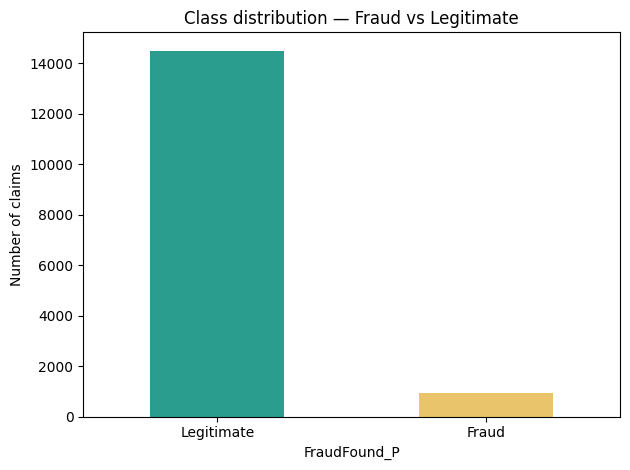

In [51]:
df['FraudFound_P'].value_counts().plot(kind='bar', color=[TEAL,AMBER])
plt.title('Class distribution — Fraud vs Legitimate')
plt.ylabel('Number of claims')
plt.xticks([0, 1], ['Legitimate', 'Fraud'], rotation=0)
plt.tight_layout()
plt.show()

## Data Quality

In [26]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())

Duplicate rows: 0
Missing values: 0


In [27]:
print("Age=0 rows:", (df['Age'] == 0).sum())
print("All Age=0 match AgeOfPolicyHolder '16 to 17':",
      (df.loc[df['Age'] == 0, 'AgeOfPolicyHolder'] == '16 to 17').all())

Age=0 rows: 320
All Age=0 match AgeOfPolicyHolder '16 to 17': True


In [28]:
malformed = (
    (df['DayOfWeekClaimed'].astype(str) == '0') |
    (df['MonthClaimed'].astype(str) == '0')
)
print("Malformed rows (DayOfWeekClaimed or MonthClaimed = 0):", malformed.sum())

Malformed rows (DayOfWeekClaimed or MonthClaimed = 0): 1


In [29]:
print("PolicyNumber unique values:", df['PolicyNumber'].nunique())
print("Unique per row — not a predictive feature, safe to drop")

PolicyNumber unique values: 15420
Unique per row — not a predictive feature, safe to drop


## Fraud Rate by Feature

In [32]:
cols = ['Fault', 'AccidentArea', 'PoliceReportFiled',
        'WitnessPresent', 'BasePolicy', 'VehiclePrice']

for col in cols:
    print(df.groupby(col)['FraudFound_P'].mean().sort_values(ascending=False))
    print()

Fault
Policy Holder    0.078896
Third Party      0.008831
Name: FraudFound_P, dtype: float64

AccidentArea
Rural    0.083229
Urban    0.057155
Name: FraudFound_P, dtype: float64

PoliceReportFiled
No     0.060499
Yes    0.037383
Name: FraudFound_P, dtype: float64

WitnessPresent
No     0.060001
Yes    0.034483
Name: FraudFound_P, dtype: float64

BasePolicy
All Perils    0.101596
Collision     0.072962
Liability     0.007187
Name: FraudFound_P, dtype: float64

VehiclePrice
less than 20000    0.093978
more than 69000    0.087338
40000 to 59000     0.067245
20000 to 29000     0.052110
30000 to 39000     0.049533
60000 to 69000     0.045977
Name: FraudFound_P, dtype: float64



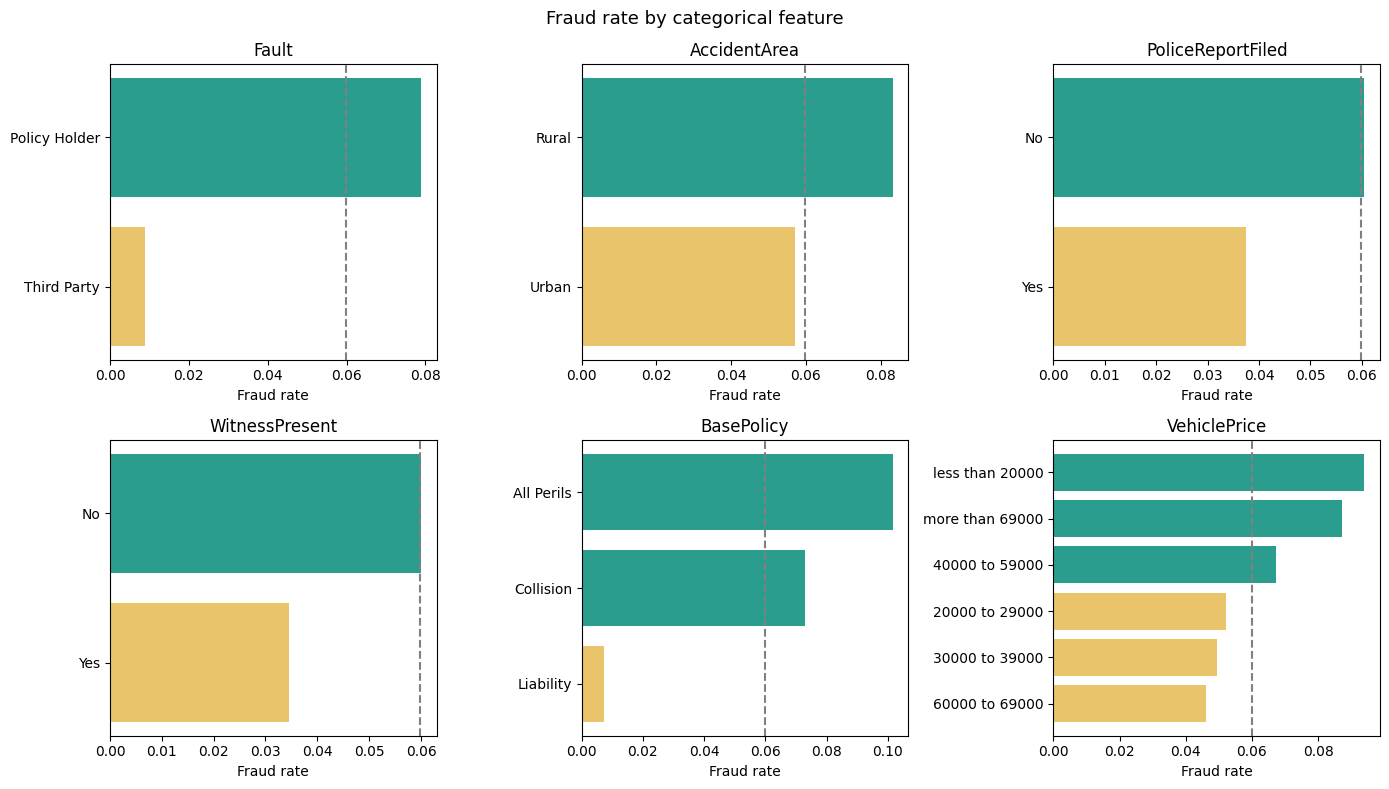

In [52]:
# Fraud rate for each category across key features
# Teal = above baseline, amber = below baseline
def fraud_rate_plot(col, ax):
    rates = df.groupby(col)['FraudFound_P'].mean().sort_values()
    baseline = df['FraudFound_P'].mean()
    colours = [TEAL if v >= baseline else AMBER for v in rates.values]
    ax.barh(rates.index, rates.values, color=colours)
    ax.axvline(baseline, color='grey', linestyle='--')
    ax.set_title(col)
    ax.set_xlabel('Fraud rate')

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

fraud_rate_plot('Fault',             axes[0, 0])
fraud_rate_plot('AccidentArea',      axes[0, 1])
fraud_rate_plot('PoliceReportFiled', axes[0, 2])
fraud_rate_plot('WitnessPresent',    axes[1, 0])
fraud_rate_plot('BasePolicy',        axes[1, 1])
fraud_rate_plot('VehiclePrice',      axes[1, 2])

plt.suptitle('Fraud rate by categorical feature', fontsize=13)
plt.tight_layout()
plt.show()

## Assessing Fraud Rate by Age Group


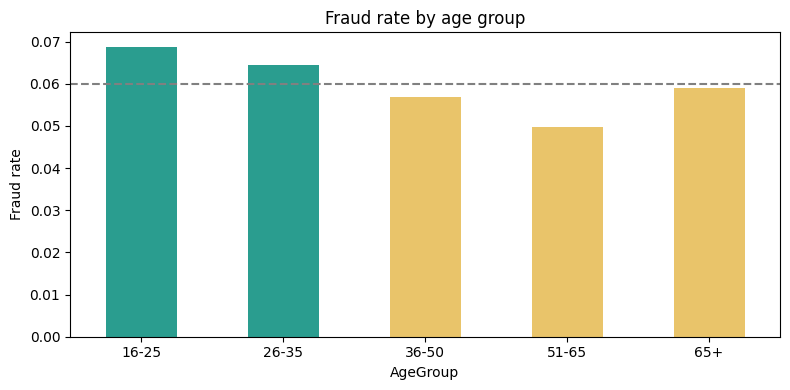

In [72]:
# Fraud rate across age groups — younger drivers associated with higher risk.
bins   = [16, 25, 35, 50, 65, 100]
labels = ['16-25', '26-35', '36-50', '51-65', '65+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

rates   = df.groupby('AgeGroup')['FraudFound_P'].mean()
baseline = df['FraudFound_P'].mean()
colours = [TEAL if v >= baseline else AMBER for v in rates.values]

rates.plot(kind='bar', color=colours, figsize=(8, 4))
plt.axhline(baseline, color='grey', linestyle='--')
plt.title('Fraud rate by age group')
plt.ylabel('Fraud rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Fraud Rate by Number of Past Claims

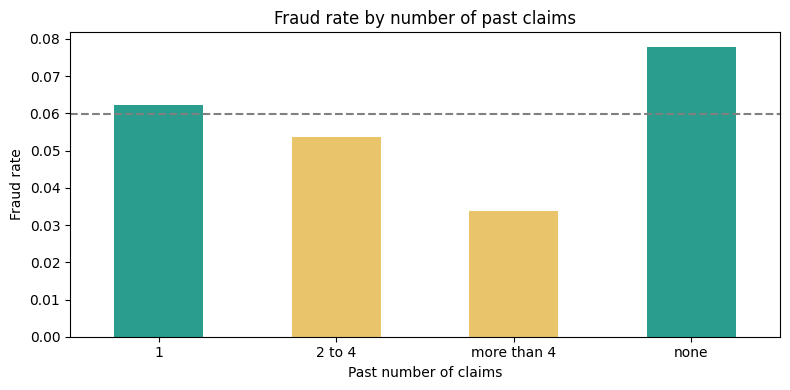

In [73]:
# Fraud rate by number of past claims
# repeat claimants may indicate suspicious behaviour.
rates = df.groupby('PastNumberOfClaims')['FraudFound_P'].mean()
baseline = df['FraudFound_P'].mean()
colours = [TEAL if v >= baseline else AMBER for v in rates.values]

rates.plot(kind='bar', color=colours, figsize=(8, 4))
plt.axhline(baseline, color='grey', linestyle='--')
plt.title('Fraud rate by number of past claims')
plt.ylabel('Fraud rate')
plt.xlabel('Past number of claims')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Fraud Rate by Address Change Recency

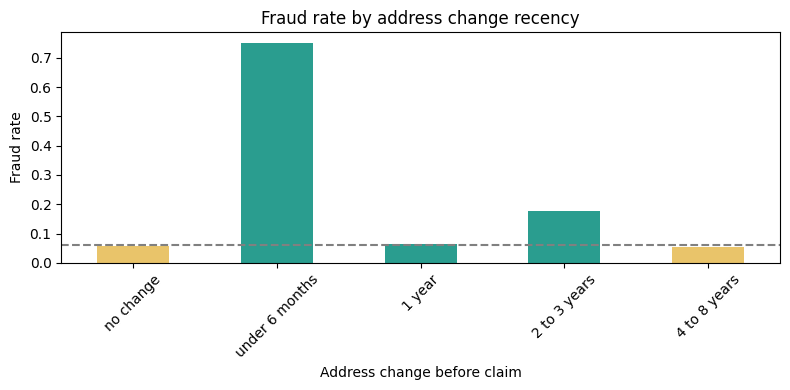

In [74]:
# Fraud rate by how recently the claimant changed address —
# recent movers before filing a claim is a known fraud indicator.
order = ['no change', 'under 6 months', '1 year', '2 to 3 years', '4 to 8 years']

rates = df.groupby('AddressChange_Claim')['FraudFound_P'].mean().reindex(order)
baseline = df['FraudFound_P'].mean()
colours = [TEAL if v >= baseline else AMBER for v in rates.values]

rates.plot(kind='bar', color=colours, figsize=(8, 4))
plt.axhline(baseline, color='grey', linestyle='--')
plt.title('Fraud rate by address change recency')
plt.ylabel('Fraud rate')
plt.xlabel('Address change before claim')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Fraud Rate by Fault

In [70]:
# Compares fraud rate between policy holder at fault
# and third party at fault claims.
df.groupby('Fault')['FraudFound_P'].mean()

,FraudFound_P
Fault,
Policy Holder,0.078896
Third Party,0.008831


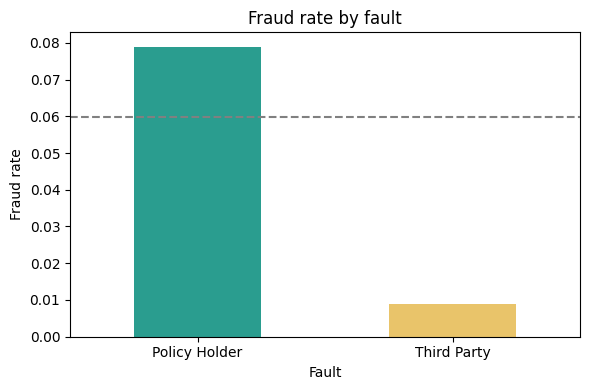

In [71]:
rates = df.groupby('Fault')['FraudFound_P'].mean()
baseline = df['FraudFound_P'].mean()
colours = [TEAL if v >= baseline else AMBER for v in rates.values]

rates.plot(kind='bar', color=colours, figsize=(6, 4))
plt.axhline(baseline, color='grey', linestyle='--')
plt.title('Fraud rate by fault')
plt.ylabel('Fraud rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## RepNumber Fraud Rate

In [67]:
# Fraud rate by claims representative
df.groupby('RepNumber')['FraudFound_P'].mean().sort_values(ascending=False)

,FraudFound_P
RepNumber,
6,0.070064
7,0.069224
10,0.066937
9,0.065065
13,0.065022
1,0.063830
3,0.063224
14,0.060574
11,0.059072


## Fraud Rate by Vehicle Make

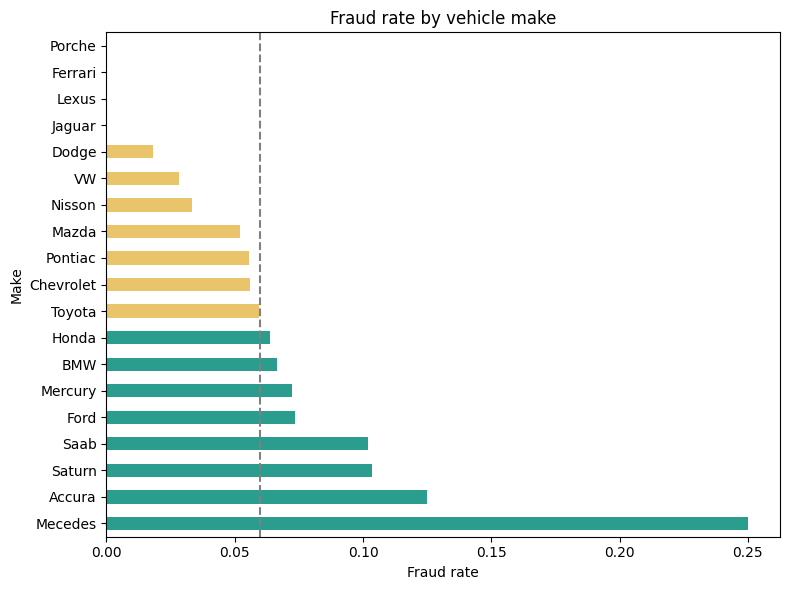

In [69]:
# Fraud rate by vehicle manufacturer.
# Wide variation across makes justifies target encoding in modelling.
rates = df.groupby('Make')['FraudFound_P'].mean().sort_values(ascending=False)
baseline = df['FraudFound_P'].mean()
colours = [TEAL if v >= baseline else AMBER for v in rates.values]

rates.plot(kind='barh', color=colours, figsize=(8, 6))
plt.axvline(baseline, color='grey', linestyle='--')
plt.title('Fraud rate by vehicle make')
plt.xlabel('Fraud rate')
plt.tight_layout()
plt.show()

## Fraud Rate by Evidence Type

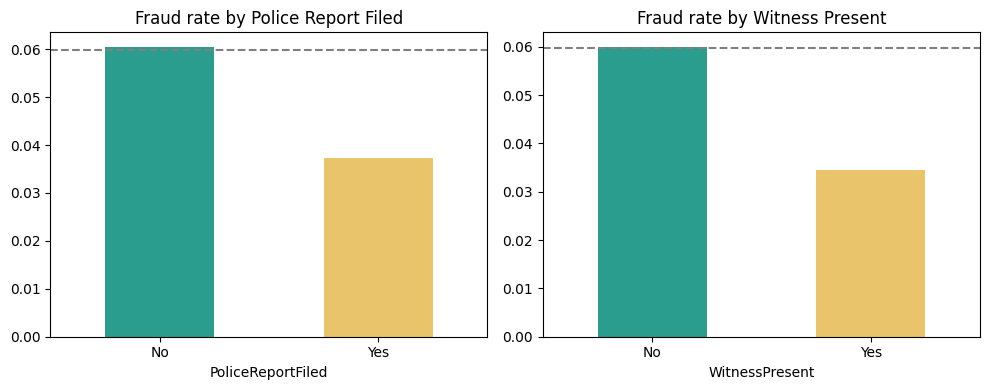

In [49]:
# Plots showing fraud rate by PoliceReportFiled and WitnessPresent
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df.groupby('PoliceReportFiled')['FraudFound_P'].mean().plot(
    kind='bar', color=[TEAL, AMBER], ax=axes[0])
axes[0].axhline(df['FraudFound_P'].mean(), color='grey', linestyle='--')
axes[0].set_title('Fraud rate by Police Report Filed')
axes[0].tick_params(rotation=0)

df.groupby('WitnessPresent')['FraudFound_P'].mean().plot(
    kind='bar', color=[TEAL, AMBER], ax=axes[1])
axes[1].axhline(df['FraudFound_P'].mean(), color='grey', linestyle='--')
axes[1].set_title('Fraud rate by Witness Present')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.show()

## Fraud Rate By Day of Week

In [45]:
df.groupby('DayOfWeek')['FraudFound_P'].mean().sort_values(ascending=False)

,FraudFound_P
DayOfWeek,
Sunday,0.069914
Saturday,0.066599
Friday,0.062986
Monday,0.061162
Thursday,0.055223
Wednesday,0.053265
Tuesday,0.052174


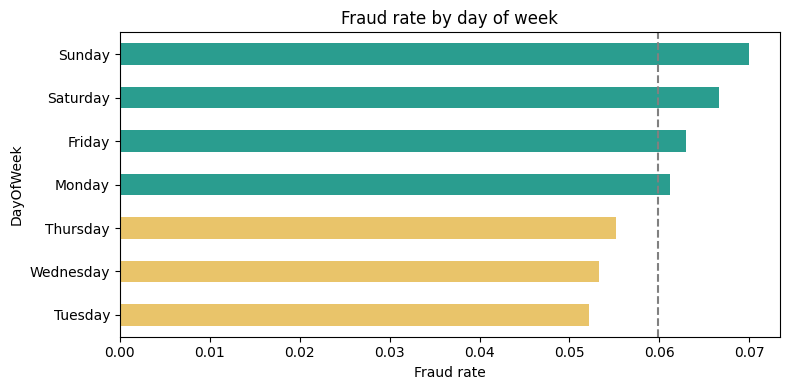

In [54]:
# Groups claims by day of week and compares fraud rate across all days.
baseline = df['FraudFound_P'].mean()
rates = df.groupby('DayOfWeek')['FraudFound_P'].mean().sort_values()
colours = [TEAL if v >= baseline else AMBER for v in rates.values]

rates.plot(kind='barh', color=colours, figsize=(8, 4))
plt.axvline(baseline, color='grey', linestyle='--')
plt.title('Fraud rate by day of week')
plt.xlabel('Fraud rate')
plt.tight_layout()
plt.show()

DayOfWeek
Weekday    0.057214
Weekend    0.068151
Name: FraudFound_P, dtype: float64


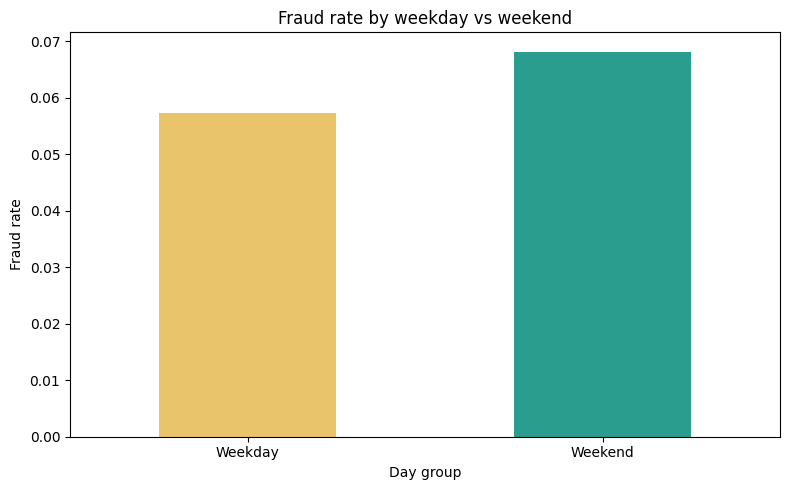

In [46]:
# Group days into weekday and weekend and compare fraud rate
day_group = df['DayOfWeek'].replace({
    'Monday': 'Weekday', 'Tuesday': 'Weekday',
    'Wednesday': 'Weekday', 'Thursday': 'Weekday',
    'Friday': 'Weekday', 'Saturday': 'Weekend',
    'Sunday': 'Weekend'
})

weekend_rates = df.groupby(day_group)['FraudFound_P'].mean()
print(weekend_rates)

weekend_rates = weekend_rates.reindex(['Weekday', 'Weekend'])
weekend_rates.plot(kind='bar', color=[AMBER, TEAL], figsize=(8, 5))
plt.title('Fraud rate by weekday vs weekend')
plt.ylabel('Fraud rate')
plt.xlabel('Day group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Fraud Rate by Vehicle and Policy Type

In [57]:
# Groups claims by VehiclePrice and BasePolicy combination
# to identify whether low value vehicles on full coverage
# have a higher fraud rate — motivates LowPriceHighInsured.
order = ['less than 20000', '20000 to 29000', '30000 to 39000',
         '40000 to 59000', '60000 to 69000', 'more than 69000']

rates = (
    df.groupby(['VehiclePrice', 'BasePolicy'])['FraudFound_P']
      .mean()
      .unstack()
      .reindex(order)
)

print("Fraud rate:")
display(rates)

Fraud rate:


BasePolicy,All Perils,Collision,Liability
VehiclePrice,,,
less than 20000,0.113429,0.065041,0.000000
20000 to 29000,0.094340,0.061926,0.006447
30000 to 39000,0.076119,0.080087,0.008802
40000 to 59000,0.123894,0.092025,0.010811
60000 to 69000,0.136364,0.043478,0.000000
more than 69000,0.125926,0.107932,0.006838


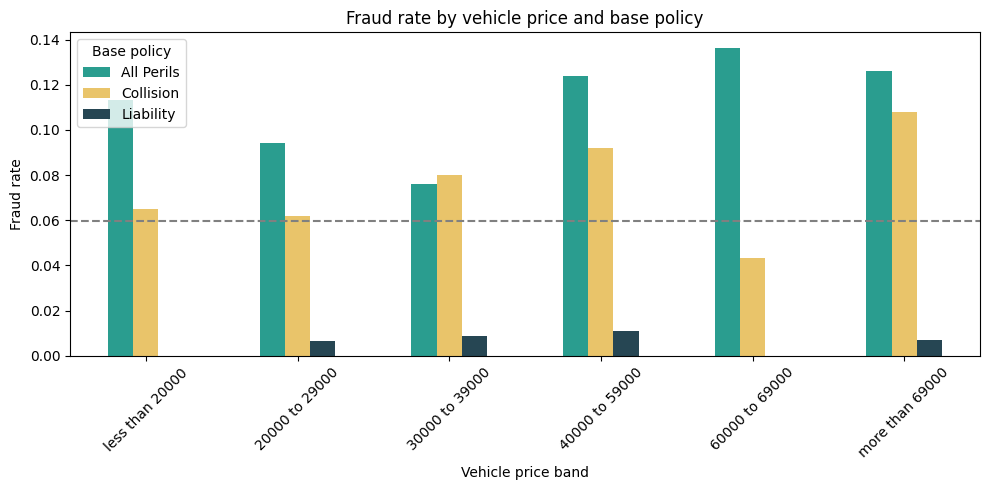

In [58]:
rates.plot(kind='bar', color=[TEAL, AMBER, DARK], figsize=(10, 5))
plt.axhline(df['FraudFound_P'].mean(), color='grey', linestyle='--')
plt.title('Fraud rate by vehicle price and base policy')
plt.ylabel('Fraud rate')
plt.xlabel('Vehicle price band')
plt.xticks(rotation=45)
plt.legend(title='Base policy')
plt.tight_layout()
plt.show()

## Temporal Pattern


In [60]:
# Fraud rate and claim volume by year.
df.groupby('Year')['FraudFound_P'].agg(['mean', 'count', 'sum'])

,mean,count,sum
Year,,,
1994,0.066591,6142,409
1995,0.057940,5195,301
1996,0.052168,4083,213


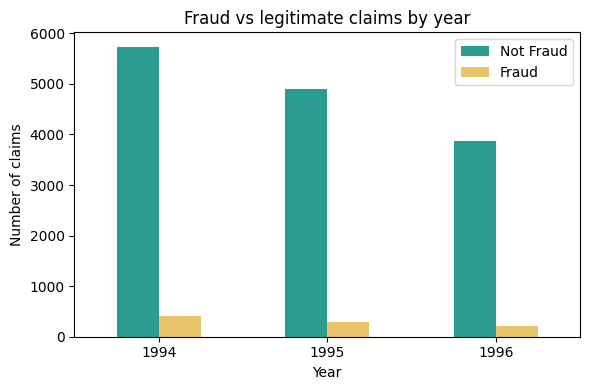

In [66]:
# Claim count split by fraud and non-fraud for each year.
year_counts = df.groupby(['Year', 'FraudFound_P']).size().unstack()
year_counts.columns = ['Not Fraud', 'Fraud']

year_counts.plot(kind='bar', color=[TEAL, AMBER], figsize=(6, 4))
plt.title('Fraud vs legitimate claims by year')
plt.ylabel('Number of claims')
plt.xlabel('Year')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

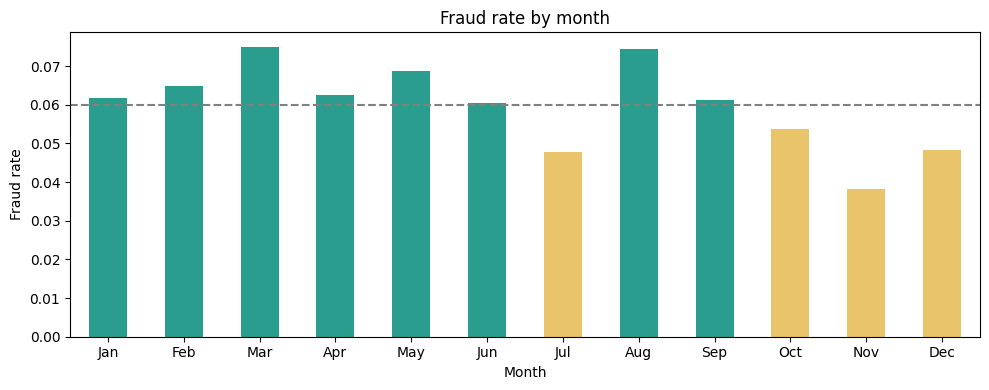

In [62]:
# Fraud rate by month to identify seasonal patterns.
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

rates = df.groupby('Month')['FraudFound_P'].mean().reindex(month_order)
baseline = df['FraudFound_P'].mean()
colours = [TEAL if v >= baseline else AMBER for v in rates.values]

rates.plot(kind='bar', color=colours, figsize=(10, 4))
plt.axhline(baseline, color='grey', linestyle='--')
plt.title('Fraud rate by month')
plt.ylabel('Fraud rate')
plt.xlabel('Month')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Correlation Heatmap

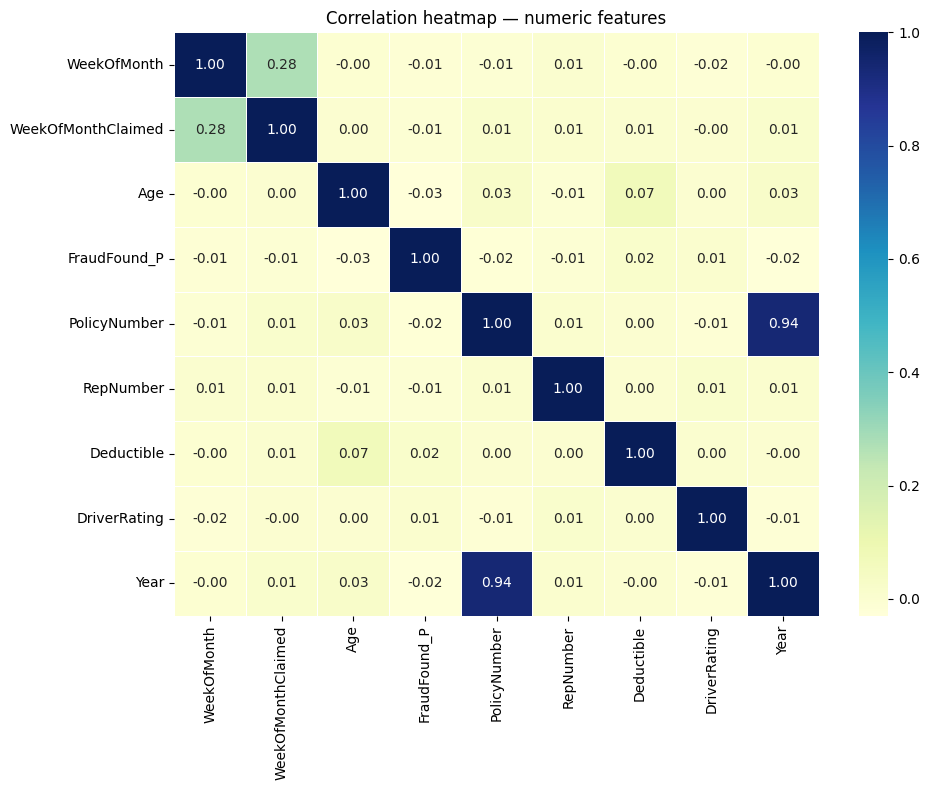

In [64]:
# Correlation between numeric features.
# Helps identify redundant or highly correlated features.
import seaborn as sns

numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.5)
plt.title('Correlation heatmap — numeric features')
plt.tight_layout()
plt.show()